In [1]:
import os, sys
sys.path.append("../")
import numpy as np
import pandas as pd
import torch 
from torch import nn
from torch.utils.data import DataLoader
import scanpy as sc

from matplotlib import pyplot as plt

In [2]:
from PINN import models
from PINN.reader import Pdyn_ExtractDataset

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import PINN 
from PINN import pl 

# read data

In [5]:
pt_path = '../data/HSPC_clu7.pt'

train_DS = Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=300, n_repeat=10)
# val_DS= Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=600, n_repeat=1)

train_iter = iter(DataLoader(train_DS, batch_size=1, num_workers=4))

# val_DL = DataLoader(val_DS, batch_size=1, num_workers=4)

In [6]:
data_batch = next(train_iter)

# version 0

In [18]:
main_dir = "/ssd/users/wergillius/Project/PINN_dynamics"

# v3
ckpt0 = "../logs/HSPC_clu7/Cspline_PINN_RandMiniB/lightning_logs/version_0/checkpoints/epoch=278-total_loss=0.20281696.ckpt"
modelv0 = models.Cspline_PINN.load_from_checkpoint(ckpt0).to('cpu')

/home/wergillius/.local/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


[3.3461976 4.090822  5.2018147 6.056324  6.6656523 7.189351  7.5017204
 7.757004  8.27516  ]
[3.4428031 4.336933  5.0695786 6.051866  6.076313  7.437585  7.578979
 6.7438884 8.840208 ]


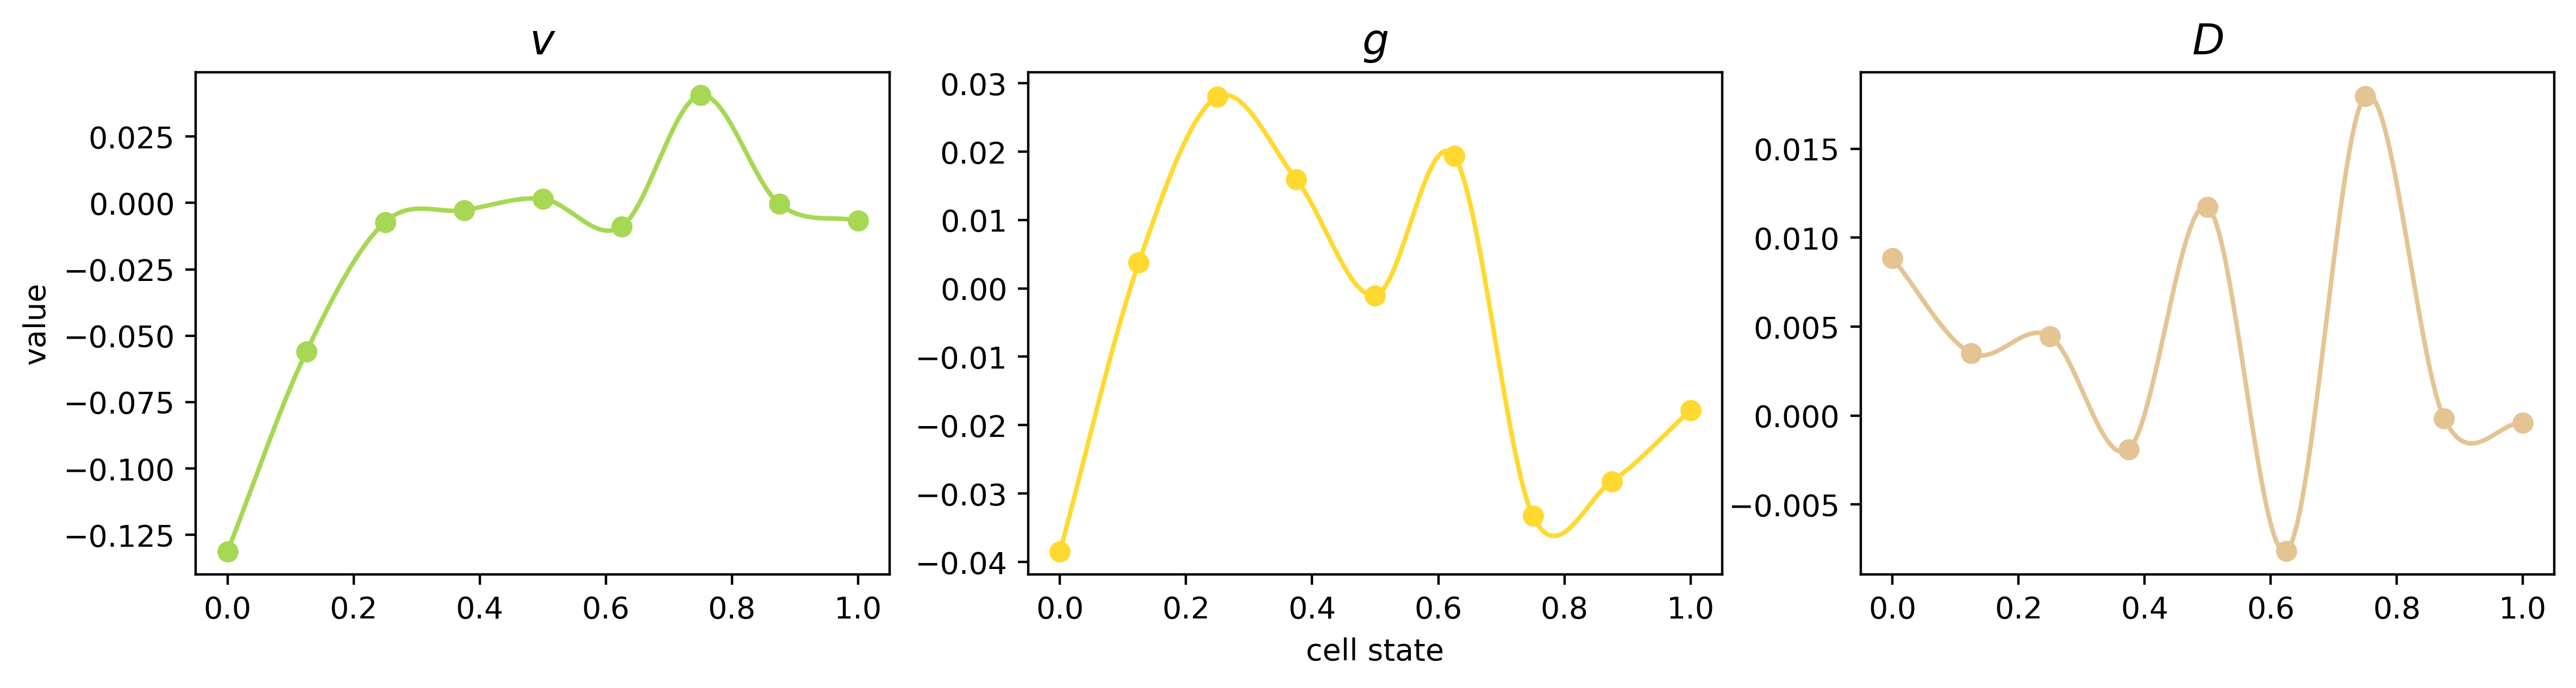

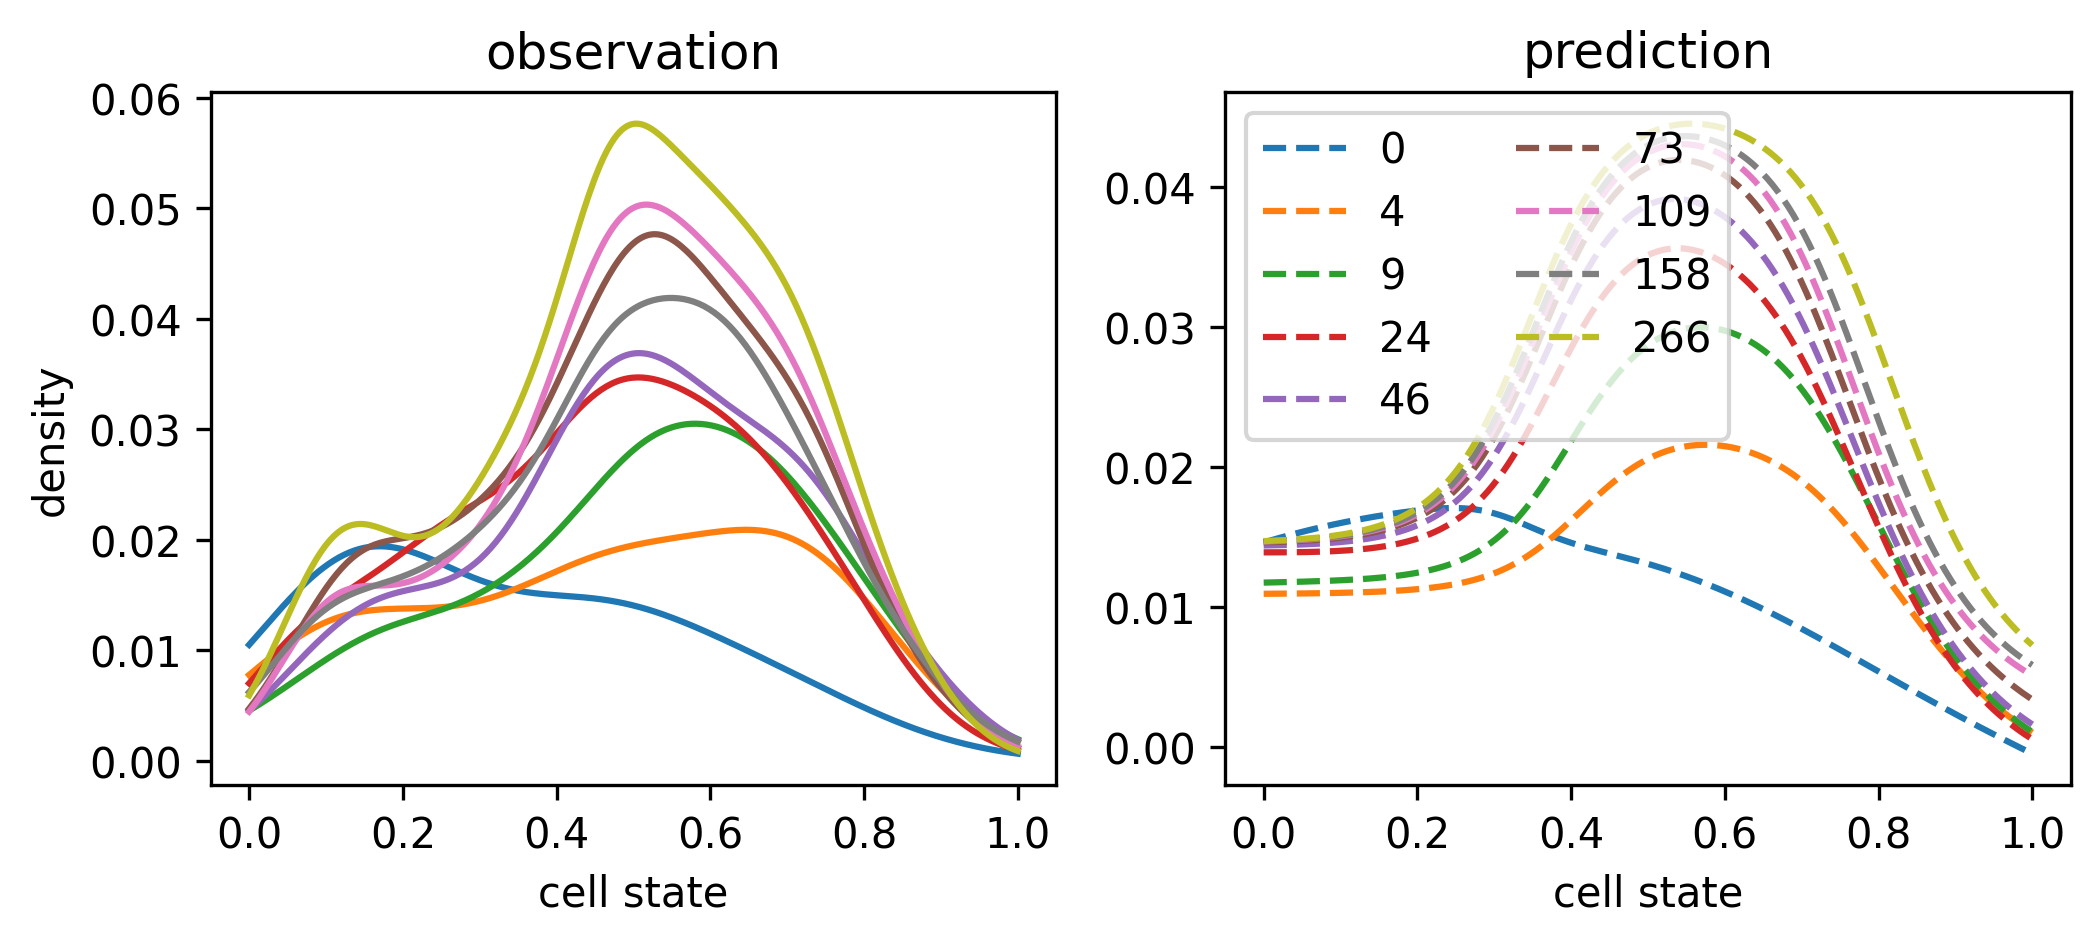

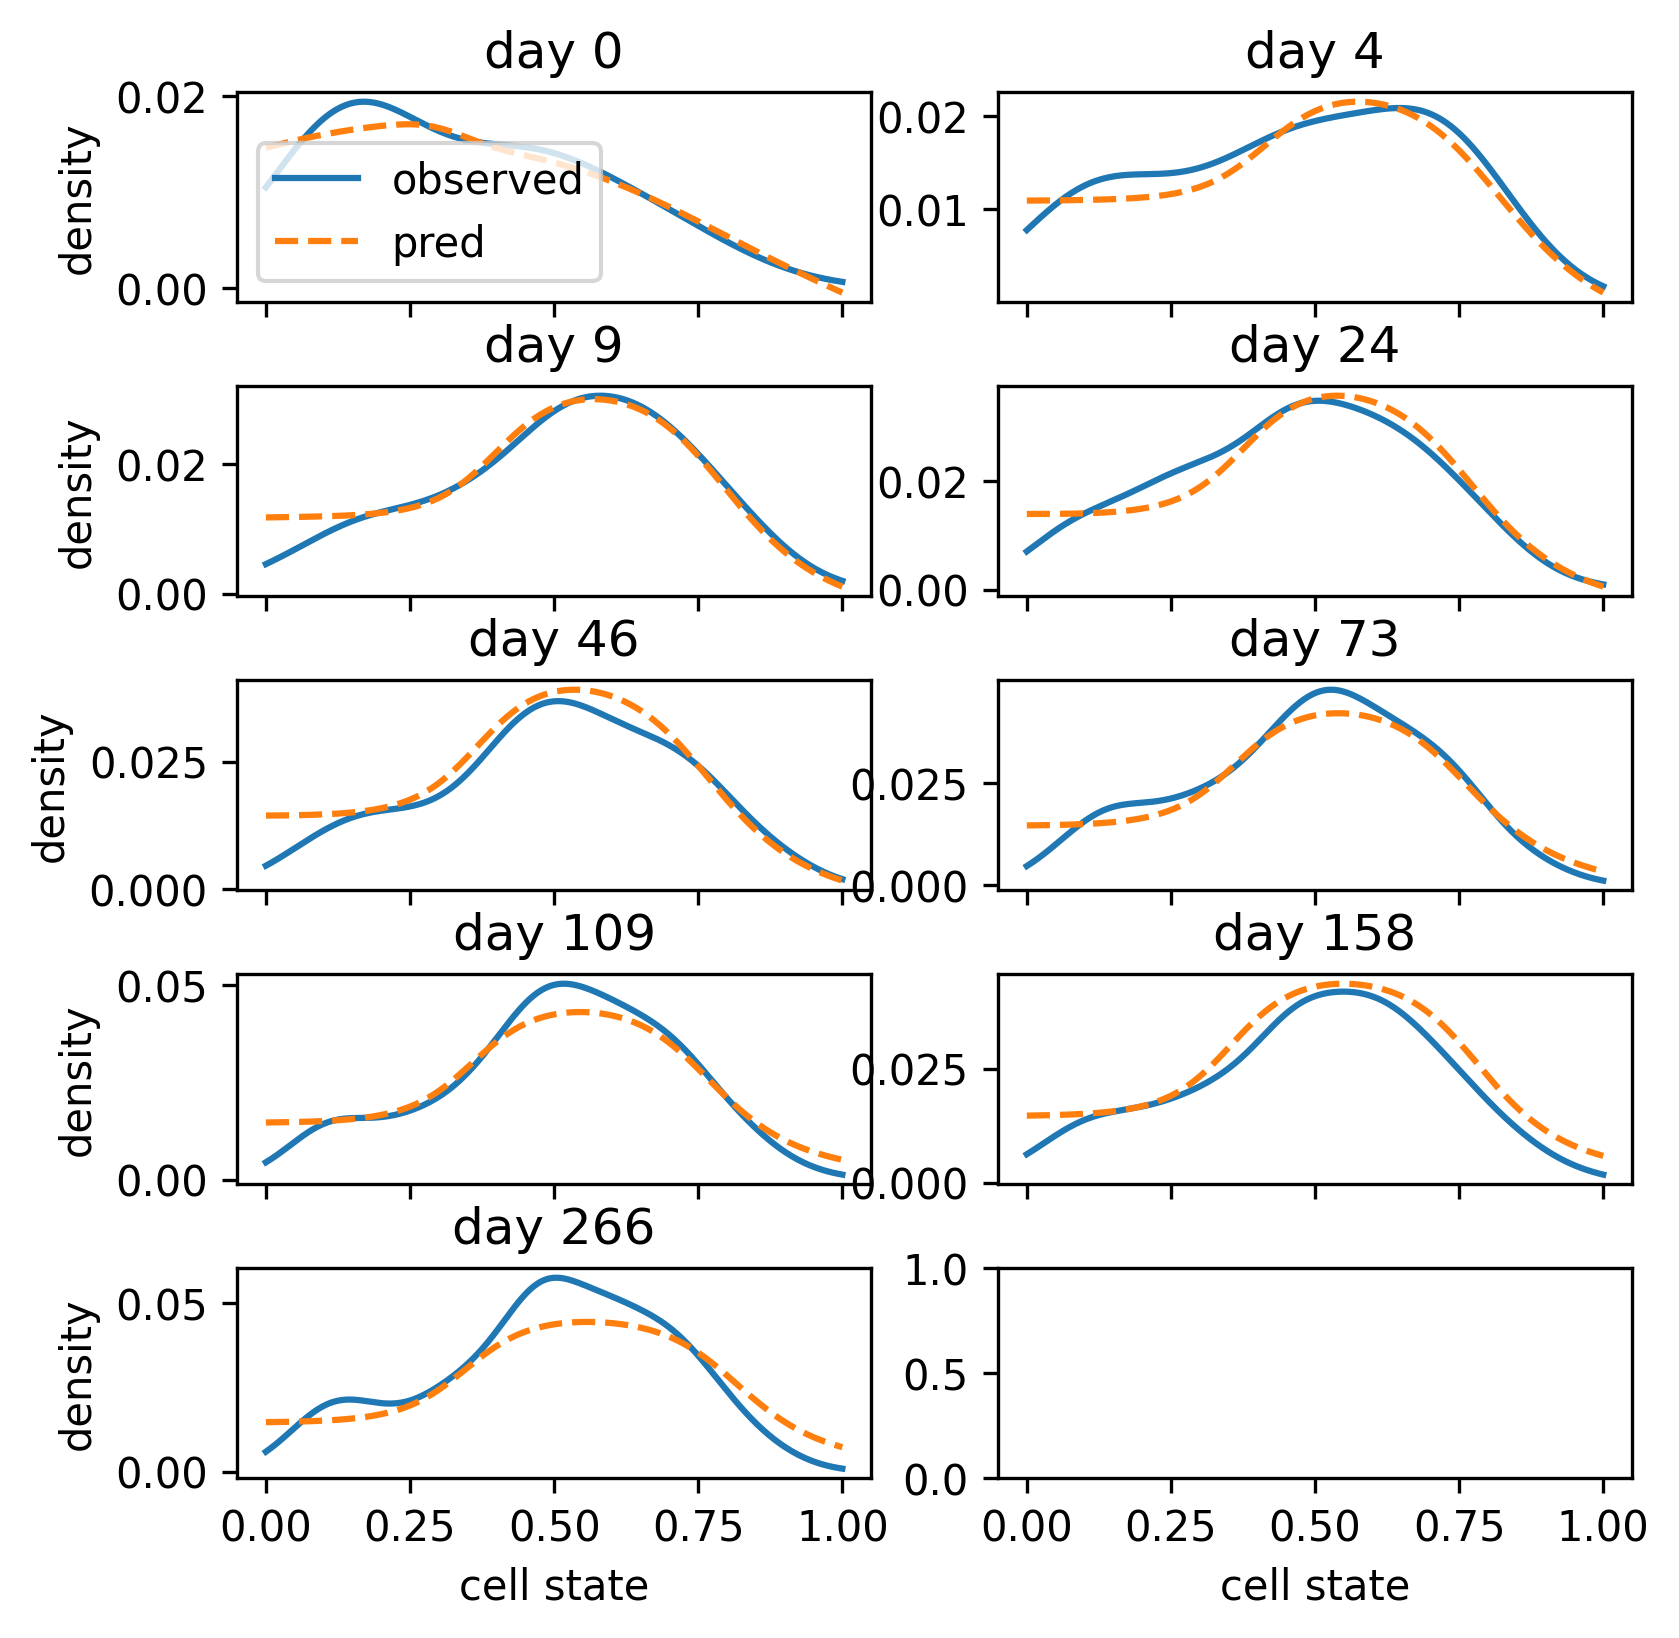

In [22]:
u_pred_b = pl.predict_and_vis(modelv0, data_batch, train_DS)

In [45]:
data_path = "/home/wergillius/Project/HSPCdynamics/procdata/04script/"
ad = sc.read_h5ad(f"{data_path}/combined_filt.h5ad")

In [47]:
clu7_df = pd.read_csv("/home/wergillius/Project/HSPCdynamics/PD_model/clu_7/tables/table_all_parameters_clu_7.csv", index_col=0)

In [48]:
clu7_ad = ad[clu7_df.index].copy()
clu7_ad

AnnData object with n_obs × n_vars = 8704 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR'
    var: 'symbol', 'gene_ids-10x', 'feature_types-10x', 'genome-10x', 'n_counts-10x', 'highly_v

In [50]:
clu7_ad = pl.evaluate_behavior_for_cell(ad, modelv0, dpt_key='dpt_pseudotime')

/home/wergillius/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


AttributeError: PathCollection.set() got an unexpected keyword argument 'colors'

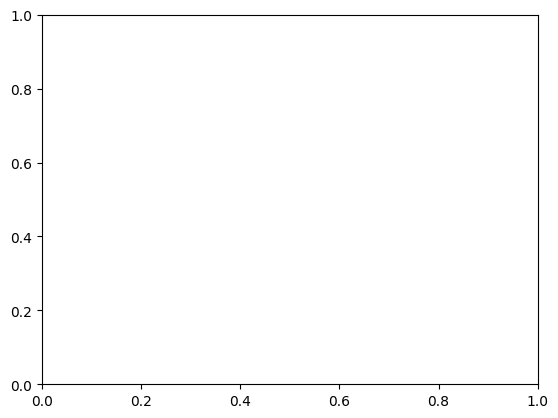

In [52]:
sc.pl.umap(clu7_ad, colors=['PINN_v','PINN_g', 'PINN_D'])

# checkpoint 1

In [40]:
main_dir = "/ssd/users/wergillius/Project/PINN_dynamics"

# v3
ckpt1 = "../logs/HSPC_clu7/Cspline_PINN_RandMiniB/lightning_logs/version_2/checkpoints/epoch=62-total_loss=0.20147032.ckpt"
modelv1 = models.Cspline_PINN.load_from_checkpoint(ckpt1).to('cpu')

[ 1.098157   2.5079813  4.929296   3.143318  -2.283655  -3.3403277
 -3.4374862 -3.4518995 -3.4320657]
[3.4428031 4.336933  5.0695786 6.051866  6.076313  7.437585  7.578979
 6.7438884 8.840208 ]


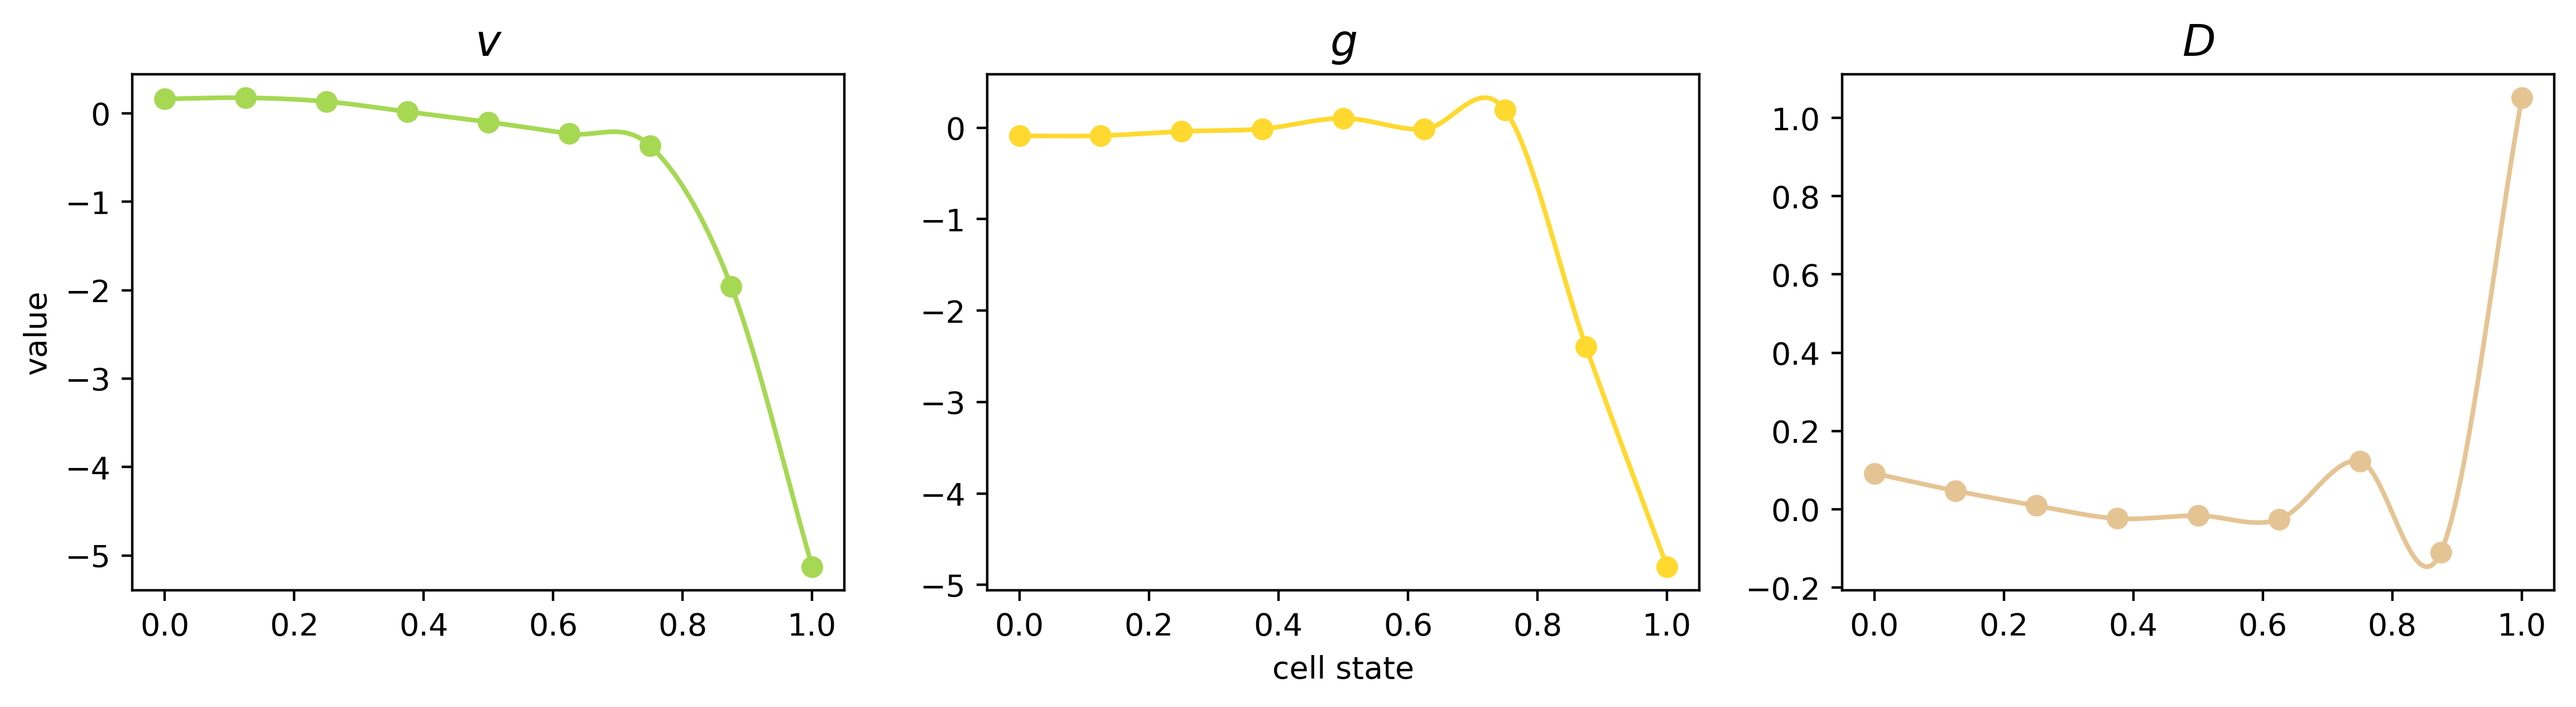

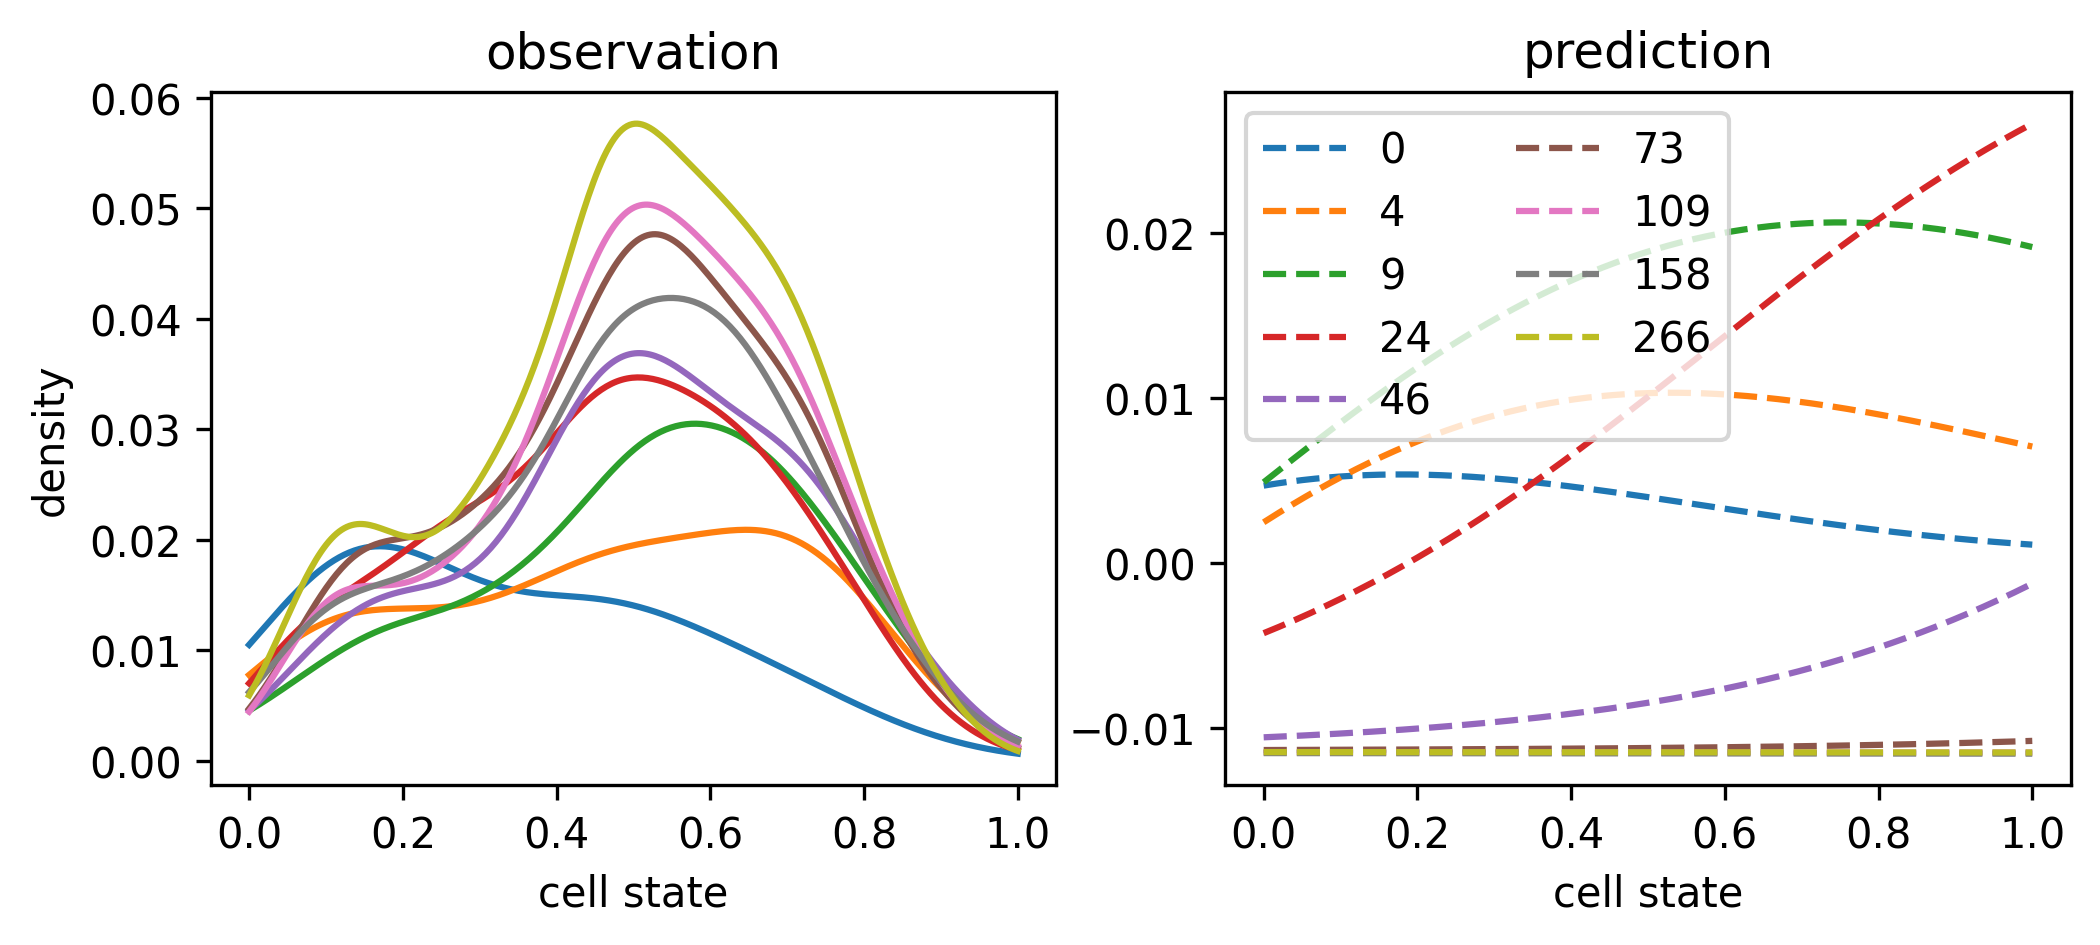

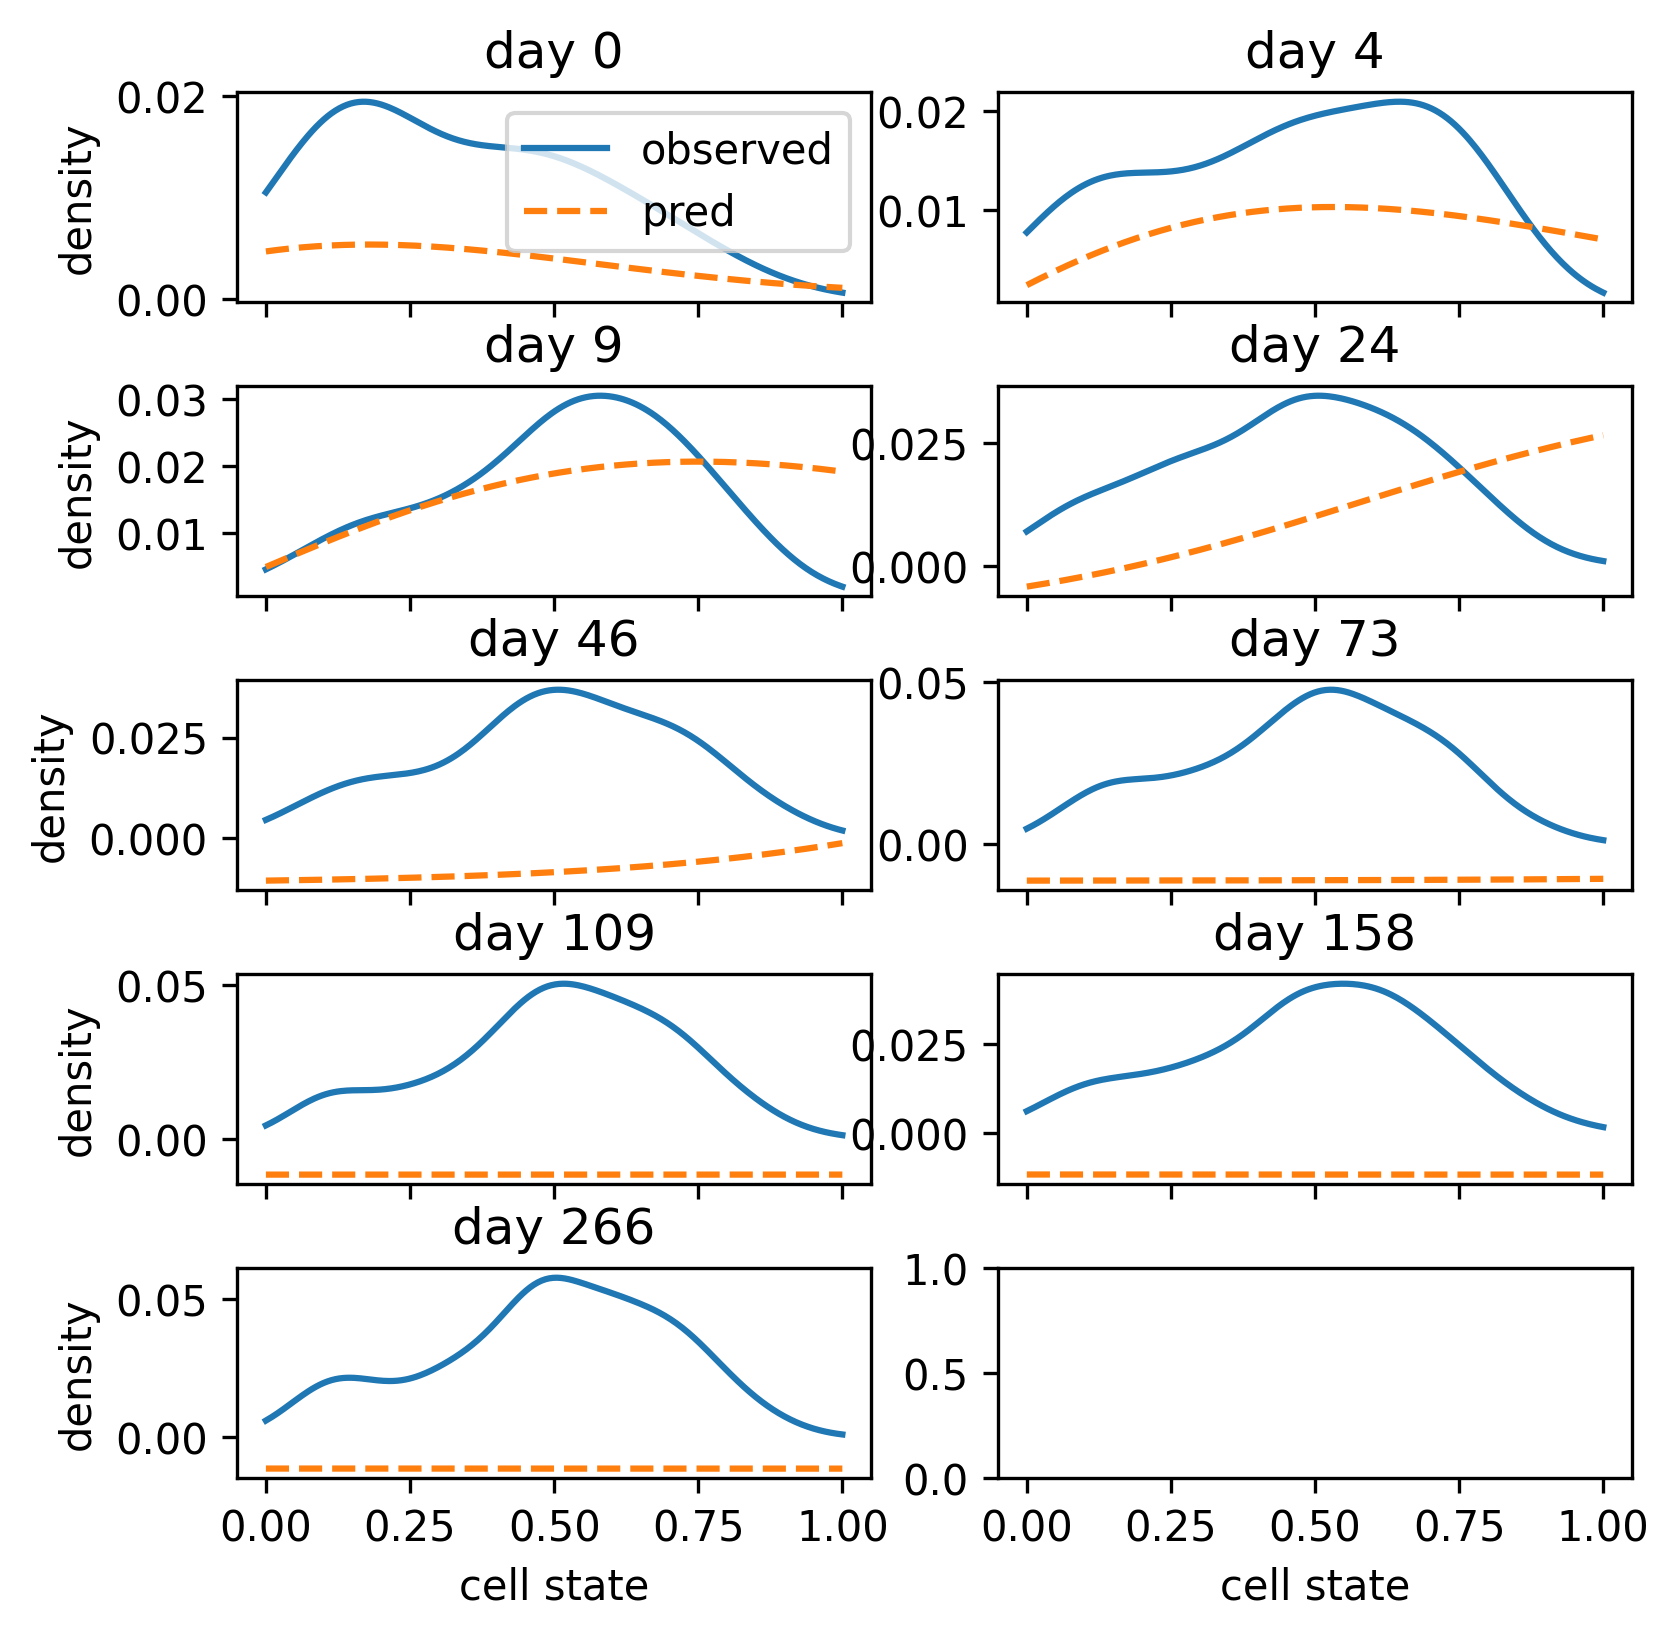

In [41]:
u_pred_b = pl.predict_and_vis(modelv1, data_batch, train_DS)

# checkpoint 2

In [7]:
main_dir = "/ssd/users/wergillius/Project/PINN_dynamics"

# v3
ckpt2 = "../logs/HSPC_clu7/Cspline_PINN_RandMiniB/lightning_logs/version_2/checkpoints/epoch=271-total_loss=0.20027761.ckpt"
modelv2 = models.Cspline_PINN.load_from_checkpoint(ckpt2).to('cpu')

/home/wergillius/.local/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


[1.1809657 1.508378  1.738889  1.9605837 2.1212606 2.2580562 2.394731
 2.5358458 2.7551713]
[3.4428031 4.336933  5.0695786 6.051866  6.076313  7.437585  7.578979
 6.7438884 8.840208 ]


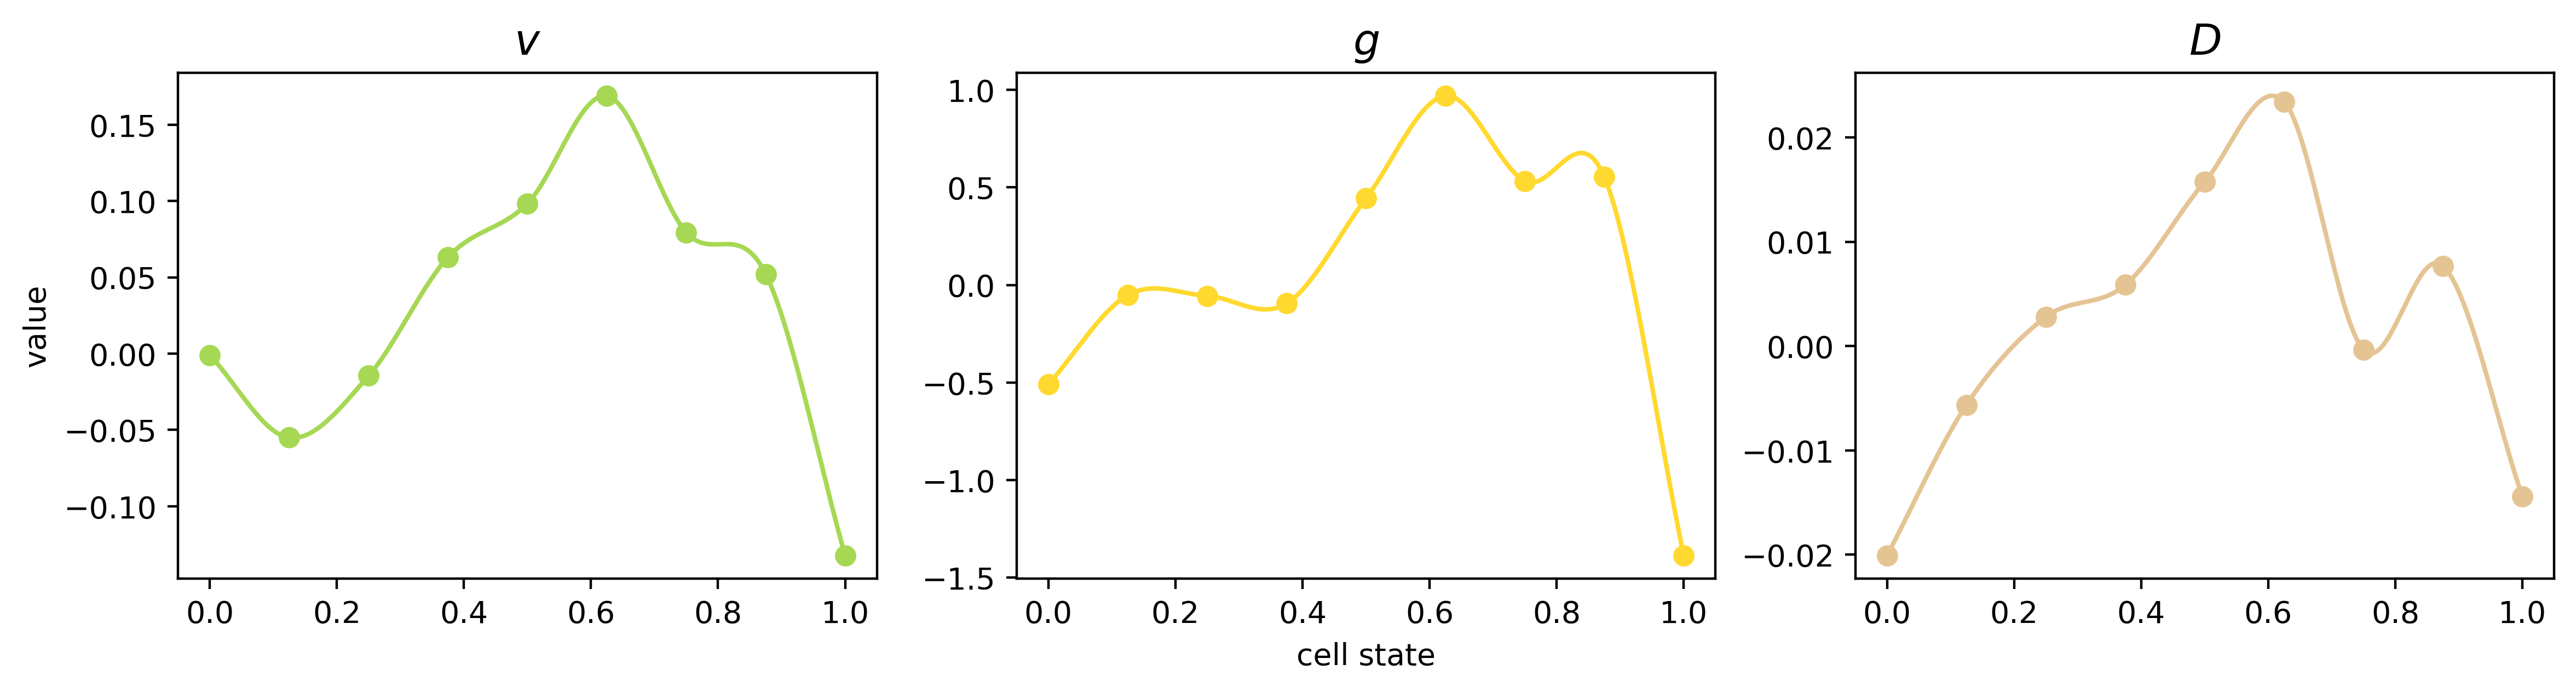

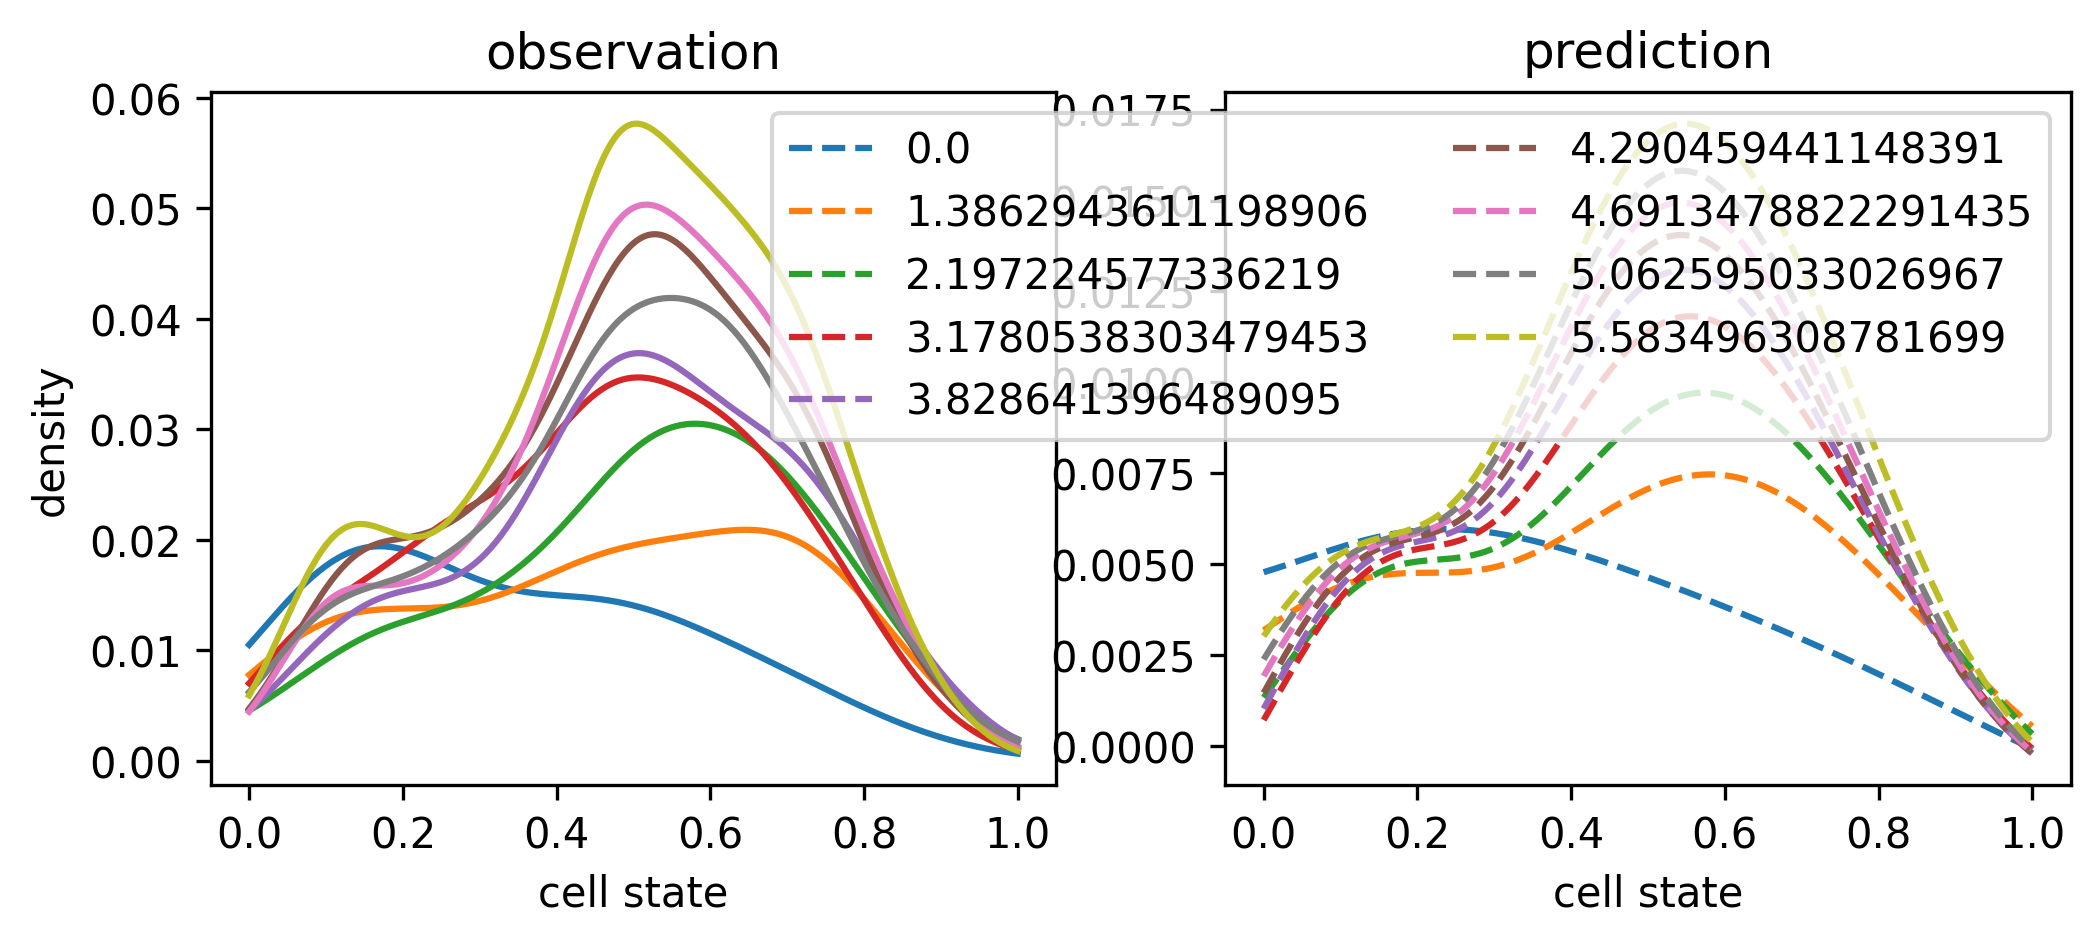

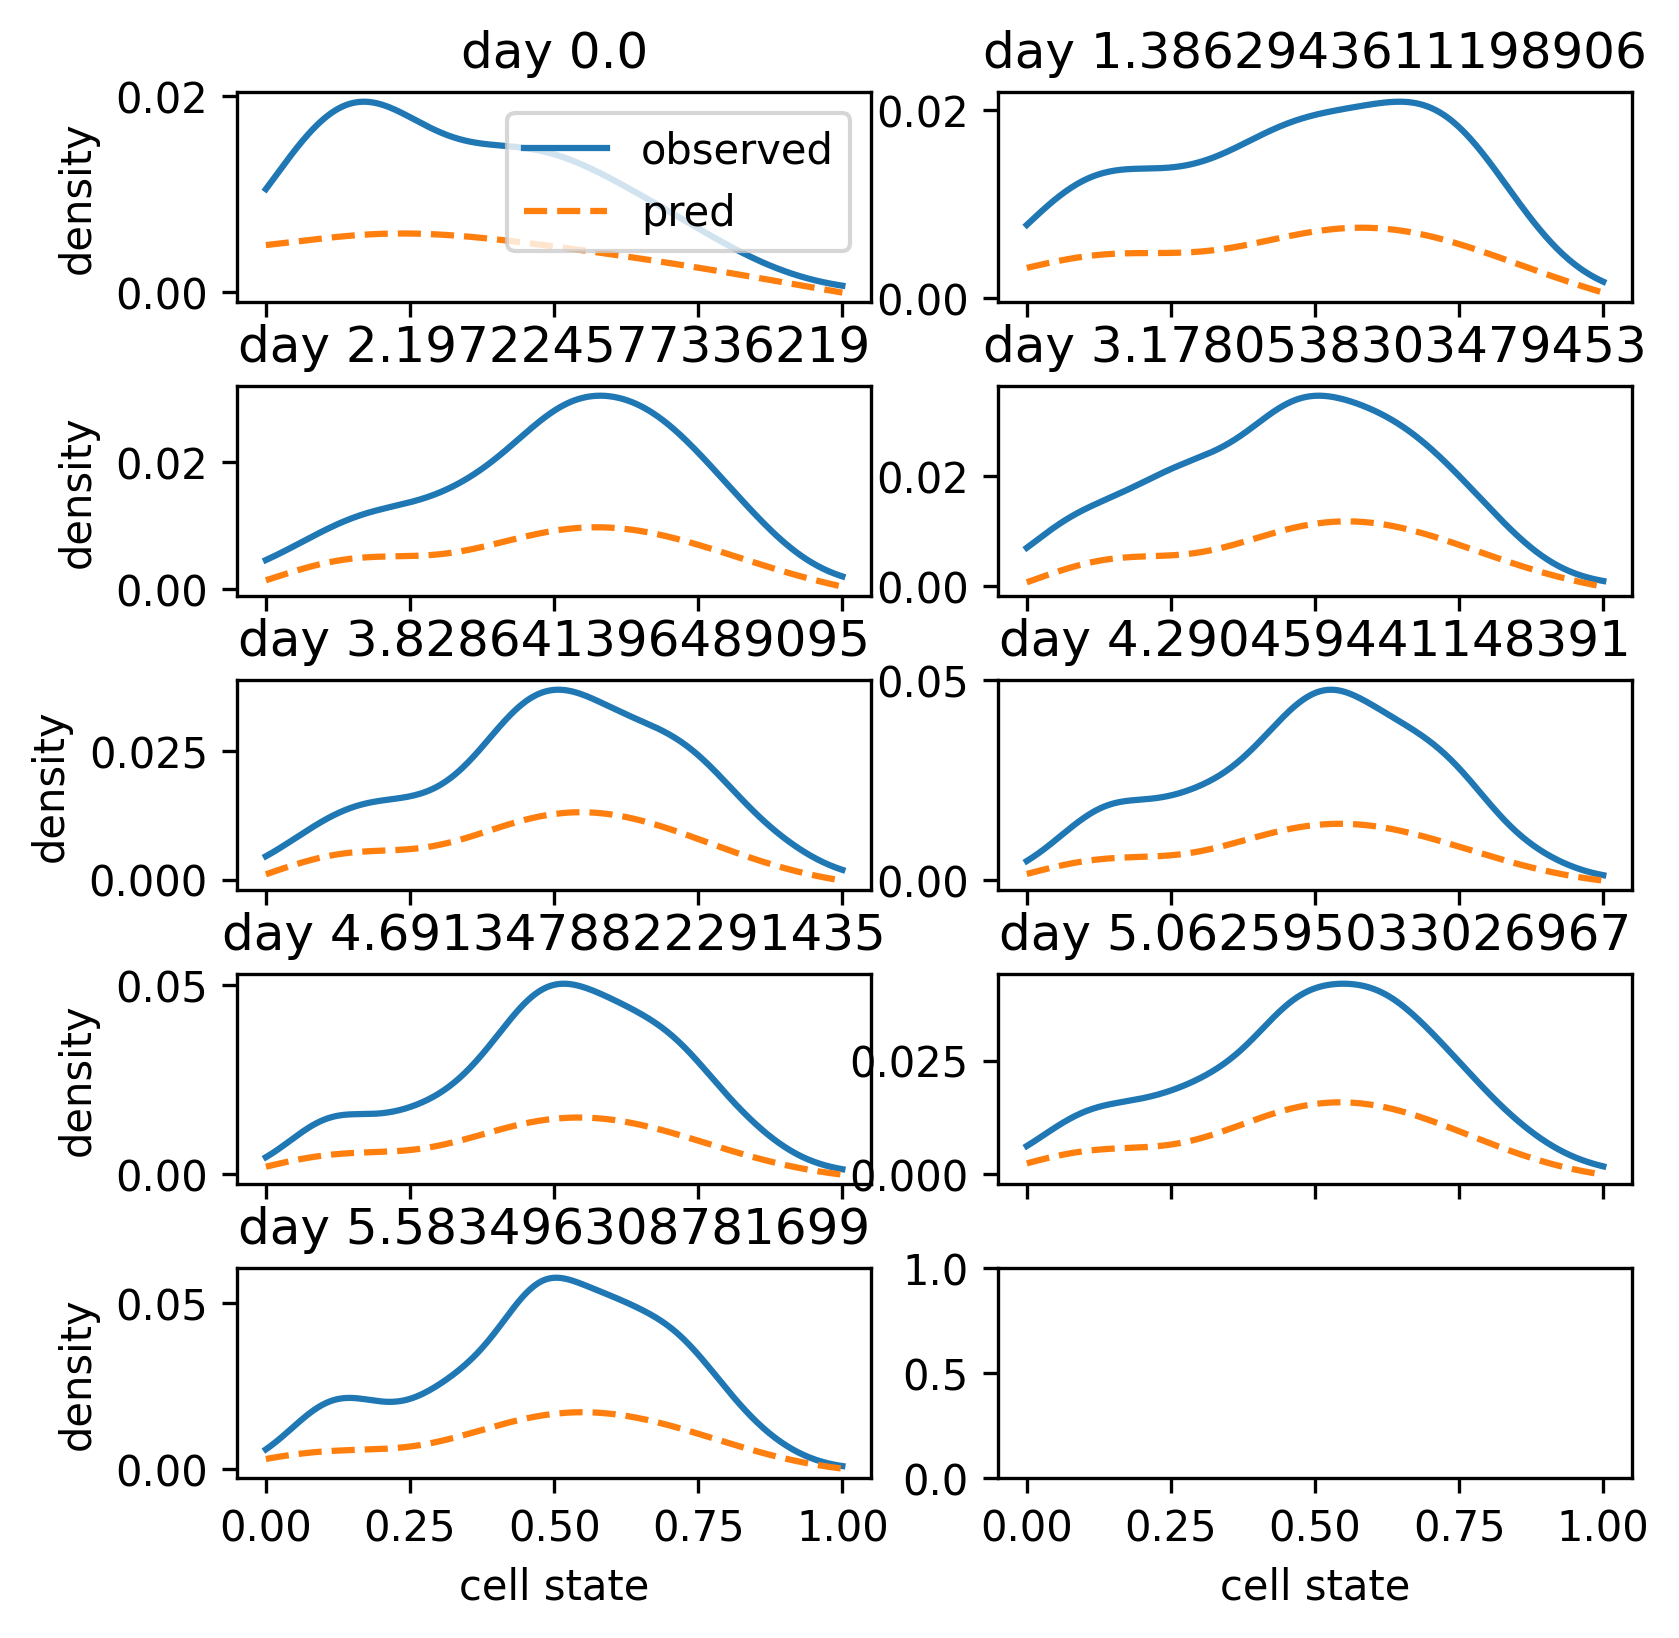

In [8]:
u_pred_b = pl.predict_and_vis(modelv2, data_batch, train_DS)